<a href="https://colab.research.google.com/github/FaridRash/brain-ct-hemorrhage-segmentation/blob/main/Notebooks/04_Multi_Windowing_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Define paths

In [24]:
import os

input_root = '/content/drive/MyDrive/brain_ct_project/brain_ct_cropped_resized'
output_root = '/content/drive/MyDrive/brain_ct_project/brain_ct_windowed_3ch'

splits = ['train', 'val', 'test']

for split in splits:
    os.makedirs(os.path.join(output_root, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_root, split, 'masks'), exist_ok=True)

#Window function

In [21]:
def apply_window(img, WL, WW):
    lower = WL - WW / 2
    upper = WL + WW / 2

    windowed = np.clip(img, lower, upper)
    normalized = (windowed - lower) / (upper - lower)

    return normalized

#Full pipeline

In [25]:
import numpy as np

for split in splits:
    img_dir = os.path.join(input_root, split, 'images')
    mask_dir = os.path.join(input_root, split, 'masks')

    out_img_dir = os.path.join(output_root, split, 'images')
    out_mask_dir = os.path.join(output_root, split, 'masks')

    files = sorted(os.listdir(img_dir))

    print(f"\nProcessing {split} | {len(files)} samples")

    for f in files:
        img = np.load(os.path.join(img_dir, f))
        mask = np.load(os.path.join(mask_dir, f))

        # --- 3 CHANNELS (DATA-DRIVEN WINDOWS) ---
        brain = apply_window(img, 40, 80)
        blood = apply_window(img, 40, 50)   # <-- your optimized one
        bone  = apply_window(img, 300, 1500)

        img_3ch = np.stack([brain, blood, bone], axis=0)

        # mask stays unchanged
        mask = np.expand_dims(mask, axis=0)

        # --- SAVE ---
        np.save(os.path.join(out_img_dir, f), img_3ch)
        np.save(os.path.join(out_mask_dir, f), mask)

    print(f"{split} done.")


Processing train | 2281 samples
train done.

Processing val | 241 samples
val done.

Processing test | 292 samples
test done.


#Validation

Shape: (3, 256, 256)
Range: 0.0 1.0


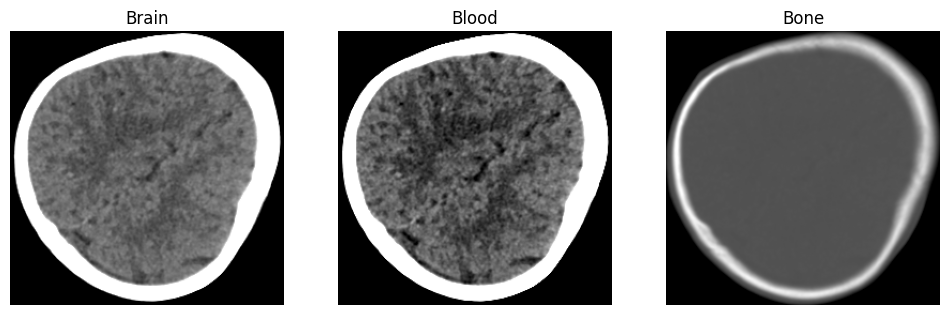

In [26]:
import random
import matplotlib.pyplot as plt

split = 'train'
img_dir = os.path.join(output_root, split, 'images')

f = random.choice(os.listdir(img_dir))

img = np.load(os.path.join(img_dir, f))

print("Shape:", img.shape)
print("Range:", img.min(), img.max())

plt.figure(figsize=(12,4))

for i, title in enumerate(['Brain', 'Blood', 'Bone']):
    plt.subplot(1,3,i+1)
    plt.title(title)
    plt.imshow(img[i], cmap='gray')
    plt.axis('off')

plt.show()

#Zip Data

In [27]:
import shutil

zip_path = '/content/brain_ct_windowed_3ch.zip'

shutil.make_archive(
    base_name=zip_path.replace('.zip', ''),
    format='zip',
    root_dir=output_root
)

print("Zip created at:", zip_path)

Zip created at: /content/brain_ct_windowed_3ch.zip


In [28]:
drive_zip_path = '/content/drive/MyDrive/brain_ct_project/brain_ct_windowed_3ch.zip'

shutil.move(zip_path, drive_zip_path)

print("Moved to:", drive_zip_path)

Moved to: /content/drive/MyDrive/brain_ct_project/brain_ct_windowed_3ch.zip
